In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../../QHamSolver/Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

from mpl_toolkits.axes_grid1 import make_axes_locatable

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{physics}\usepackage{xcolor}\usepackage{amsmath}\usepackage{amsfonts}'


%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


def base_dir(BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/" + (f"PBC/" if BC else f"OBC/")
    return dirx

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/LGT_Project/FermionQLM/Jupyter_Notebook
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../../QHamSolver/Python/


BZ path for 60x2 non-square lattice:
  Total q-points: 63
  $\Gamma$      idx=  0  ( 0, 0)  q=(0.000, 0.000)  dist=0.0000
  $X$           idx= 30  (30, 0)  q=(3.142, 0.000)  dist=3.1416
  $M$           idx= 31  (30, 1)  q=(3.142, 3.142)  dist=6.2832
  $Y$           idx= 61  ( 0, 1)  q=(0.000, 3.142)  dist=9.4248
  $\Gamma$      idx= 62  ( 0, 0)  q=(0.000, 0.000)  dist=12.5664
  Segment steps : [30, 1, 30, 1]
  Max steps     : 30
  Min steps     : 1
  Segment 0: $\Gamma$     -> $X$           steps= 30  bin_width=1.0
  Segment 1: $X$          -> $M$           steps=  1  bin_width=2.0
  Segment 2: $M$          -> $Y$           steps= 30  bin_width=1.0
  Segment 3: $Y$          -> $\Gamma$      steps=  1  bin_width=2.0


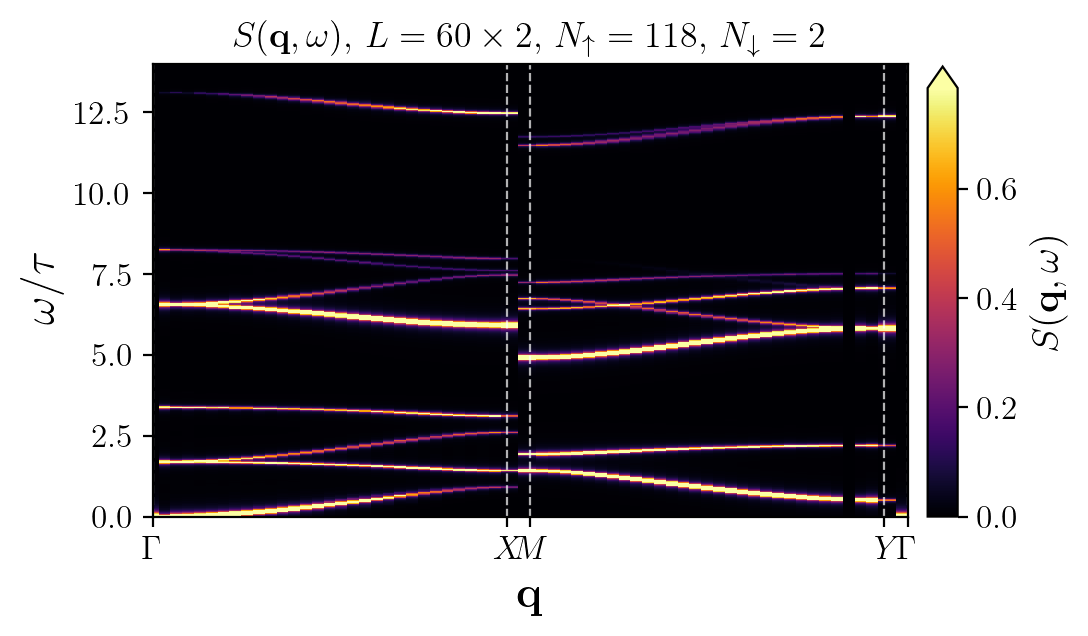

In [ ]:
Lx = 16
Ly = 16
Nu = -1
Nd = 2
tau = 1
mass = 0.5
BC = 1 #PBC: BC=1

if Nu < 0:
    Nu = Lx * Ly - Nd
if Nd < 0:
    Nd = Lx * Ly - Nu

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200)

name = base_dir(BC) + "DynamicalStructureFactor/Spin/" + info(Lx, Ly, Nu, Nd, tau, mass, ',kx=0,ky=0,px=1,py=1.hdf5')
# name = base_dir(BC) + "DynamicalStructureFactor/Spin/" + info(Lx, Ly, Nu, Nd, tau, mass, ',kx=3,ky=1,py=1.hdf5')
if exists(name):
    with h5py.File(name, "r") as file:
        omegas = np.array(file.get('omegas'))[0]
        Sqw = np.array(file.get('Sqw'))
else:
    print(name)
# ----------------------------------------------------------------
# 1. Reconstruct the BZ path (same order as stored in file)
# ----------------------------------------------------------------
path, q_vals, label_positions = get_bz_path(Lx, Ly)
q_vals = get_weighted_qvals(path, label_positions, scale_factor=2.0)

n_q = len(path)
Q, W = np.meshgrid(q_vals, omegas)  # (n_omega, n_q)

p = axis.pcolormesh(
    Q, W,
    Sqw,                           # (n_omega, n_q)
    shading    = 'nearest',
    cmap       = 'inferno',
    vmin       = 0,
    vmax       = np.percentile(Sqw, 99),
    rasterized = True
)

# High-symmetry labels and vertical lines
xtick_pos    = [q_vals[i] for i in label_positions]
xtick_labels = list(label_positions.values())
axis.set_xticks(xtick_pos)
axis.set_xticklabels(xtick_labels, fontsize=14)
for idx in label_positions:
    axis.axvline(x=q_vals[idx], color='white',
                 linewidth=0.8, linestyle='--', alpha=0.7)

axis.set_ylabel(r"$\omega/\tau$",      fontsize=16)
axis.set_xlabel(r"$\mathbf{q}$",  fontsize=16)
axis.set_xlim(q_vals[0], q_vals[-1])
axis.set_ylim(omegas.min(), omegas.max())
axis.tick_params(labelsize=12)
axis.set_title(
    rf"$S(\mathbf{{q}},\omega)$,  $L={Lx}\times{Ly}$,  "
    rf"$N_\uparrow={Nu}$,  $N_\downarrow={Nd}$",
    fontsize=13
)

if mass == 0:
    for n in range(2, 9, 2): 
        axis.axhline(y = n*np.sqrt(2), xmax=0.1, ls='--', color='white', lw=1.5)
        axis.annotate(r"$%d\sqrt{2}$"%n if n > 1 else r"$\sqrt{2}$", fontsize=10, xy=(0.75, (n+0.2)*np.sqrt(2)), xycoords='data', color='white')
    # for n in range(1, 17, 2): 
    #     axis.axhline(y = n*np.sqrt(13)/2, xmin=0.9, ls='--', color='white', lw=1.5)

# axis.axhline(y=9, ls='--', color='red', lw=0.5)

# axis.set_yscale('log')
axis.set_ylim(0, 14)
# Colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.125, 0.03, 0.75])
cbar    = fig.colorbar(p, cax=cbar_ax, orientation='vertical', extend='max')
cbar.set_label(r"$S(\mathbf{q},\omega)$", fontsize=14)
cbar.ax.tick_params(labelsize=12)

In [81]:
def get_bz_path(Lx, Ly):
    """
    BZ path:
        - Square lattice (Lx == Ly): Gamma -> X -> M -> Gamma (diagonal)
        - Non-square lattice (Lx != Ly): Gamma -> X -> M -> Y -> Gamma (rectangular)

    Returns:
        path            : list of (kx, ky) integer indices in order
        q_vals          : cumulative physical distance along path
        label_positions : {path_index: label}
    """
    path = []

    if Lx == Ly:
        # --------------------------------------------------------
        # Square lattice: Gamma(0,0) -> X(Lx/2,0) -> M(Lx/2,Ly/2) -> Gamma(0,0)
        # --------------------------------------------------------

        # Gamma(0,0) -> X(Lx/2, 0)
        for kx in range(0, Lx // 2 + 1):
            path.append((kx, 0))
        idx_Gamma1 = 0
        idx_X      = len(path) - 1      # = Lx//2

        # X(Lx/2, 0) -> M(Lx/2, Ly/2)
        for ky in range(1, Ly // 2 + 1):
            path.append((Lx // 2, ky))
        idx_M      = len(path) - 1      # = Lx//2 + Ly//2

        # M(Lx/2, Ly/2) -> Gamma(0,0) along diagonal
        for k in range(Lx // 2 - 1, -1, -1):
            path.append((k, k))
        idx_Gamma2 = len(path) - 1

        # Sanity checks
        assert path[idx_Gamma1] == (0,       0      ), f"Gamma1 wrong: {path[idx_Gamma1]}"
        assert path[idx_X]      == (Lx // 2, 0      ), f"X wrong: {path[idx_X]}"
        assert path[idx_M]      == (Lx // 2, Ly // 2), f"M wrong: {path[idx_M]}"
        assert path[idx_Gamma2] == (0,       0      ), f"Gamma2 wrong: {path[idx_Gamma2]}"

        label_positions = {
            idx_Gamma1 : r'$\Gamma$',
            idx_X      : r'$X$',
            idx_M      : r'$M$',
            idx_Gamma2 : r'$\Gamma$',
        }

    else:
        # --------------------------------------------------------
        # Non-square lattice: Gamma(0,0) -> X(Lx/2,0) -> M(Lx/2,Ly/2) -> Y(0,Ly/2) -> Gamma(0,0)
        # --------------------------------------------------------

        # Gamma(0,0) -> X(Lx/2, 0)
        for kx in range(0, Lx // 2 + 1):
            path.append((kx, 0))
        idx_Gamma1 = 0
        idx_X      = len(path) - 1      # = Lx//2

        # X(Lx/2, 0) -> M(Lx/2, Ly/2)
        for ky in range(1, Ly // 2 + 1):
            path.append((Lx // 2, ky))
        idx_M      = len(path) - 1      # = Lx//2 + Ly//2

        # M(Lx/2, Ly/2) -> Y(0, Ly/2)
        for kx in range(Lx // 2 - 1, -1, -1):
            path.append((kx, Ly // 2))
        idx_Y      = len(path) - 1      # = Lx//2 + Ly//2 + Lx//2

        # Y(0, Ly/2) -> Gamma(0,0)
        for ky in range(Ly // 2 - 1, -1, -1):
            path.append((0, ky))
        idx_Gamma2 = len(path) - 1      # = Lx//2 + Ly//2 + Lx//2 + Ly//2

        # Sanity checks
        assert path[idx_Gamma1] == (0,       0      ), f"Gamma1 wrong: {path[idx_Gamma1]}"
        assert path[idx_X]      == (Lx // 2, 0      ), f"X wrong: {path[idx_X]}"
        assert path[idx_M]      == (Lx // 2, Ly // 2), f"M wrong: {path[idx_M]}"
        assert path[idx_Y]      == (0,       Ly // 2), f"Y wrong: {path[idx_Y]}"
        assert path[idx_Gamma2] == (0,       0      ), f"Gamma2 wrong: {path[idx_Gamma2]}"

        label_positions = {
            idx_Gamma1 : r'$\Gamma$',
            idx_X      : r'$X$',
            idx_M      : r'$M$',
            idx_Y      : r'$Y$',
            idx_Gamma2 : r'$\Gamma$',
        }

    # --------------------------------------------------------
    # Common: physical q vectors and cumulative distances
    # --------------------------------------------------------
    q_vecs = np.array([
        [2 * np.pi * kx / Lx, 2 * np.pi * ky / Ly]
        for kx, ky in path
    ])

    q_vals = np.zeros(len(path))
    for i in range(1, len(path)):
        dq        = q_vecs[i] - q_vecs[i - 1]
        q_vals[i] = q_vals[i - 1] + np.linalg.norm(dq)

    # Summary
    lattice_type = "square" if Lx == Ly else "non-square"
    print(f"BZ path for {Lx}x{Ly} {lattice_type} lattice:")
    print(f"  Total q-points: {len(path)}")
    for idx, label in label_positions.items():
        kx, ky = path[idx]
        print(f"  {label:12s}  idx={idx:3d}  "
              f"({kx:2d},{ky:2d})  "
              f"q=({2*np.pi*kx/Lx:.3f}, {2*np.pi*ky/Ly:.3f})  "
              f"dist={q_vals[idx]:.4f}")

    return path, q_vals, label_positions


In [201]:
def get_weighted_qvals(path, label_positions, scale_factor=2.0):
    """
    Assign bin width = scale_factor for segments with FEWER q-points
    and bin width = 1.0 for segments with MORE q-points.

    Non-square lattice segments:
        Gamma->X  : Lx//2 steps  (sparse if Lx << Ly)
        X->M      : Ly//2 steps  (sparse if Ly << Lx)
        M->Y      : Lx//2 steps  (sparse if Lx << Ly)
        Y->Gamma  : Ly//2 steps  (sparse if Ly << Lx)

    Square lattice segments:
        Gamma->X  : Lx//2 steps
        X->M      : Ly//2 steps
        M->Gamma  : Lx//2 steps (diagonal)
    """
    idx_list   = sorted(label_positions.keys())   # [G1, X, M, (Y,) G2]
    n_segments = len(idx_list) - 1

    # Number of steps per segment
    seg_steps  = [
        idx_list[seg + 1] - idx_list[seg]
        for seg in range(n_segments)
    ]
    max_steps  = max(seg_steps)
    min_steps  = min(seg_steps)

    print(f"  Segment steps : {seg_steps}")
    print(f"  Max steps     : {max_steps}")
    print(f"  Min steps     : {min_steps}")

    q_vals = np.zeros(len(path))
    cursor = 0.0

    for seg in range(n_segments):
        i_start   = idx_list[seg]
        i_end     = idx_list[seg + 1]
        n_steps   = seg_steps[seg]

        # Scale segments with fewer points
        is_sparse = (n_steps == min_steps)
        bin_width = scale_factor if is_sparse else 1.0

        print(f"  Segment {seg}: "
              f"{list(label_positions.values())[seg]:12s} -> "
              f"{list(label_positions.values())[seg+1]:12s}  "
              f"steps={n_steps:3d}  bin_width={bin_width}")

        for i in range(i_start, i_end):
            q_vals[i] = cursor
            cursor    += bin_width

    q_vals[idx_list[-1]] = cursor      # last point (Gamma2)
    return q_vals

BZ path for 30x4 non-square lattice:
  Total q-points: 35
  $\Gamma$      idx=  0  ( 0, 0)  q=(0.000, 0.000)  dist=0.0000
  $X$           idx= 15  (15, 0)  q=(3.142, 0.000)  dist=3.1416
  $M$           idx= 17  (15, 2)  q=(3.142, 3.142)  dist=6.2832
  $Y$           idx= 32  ( 0, 2)  q=(0.000, 3.142)  dist=9.4248
  $\Gamma$      idx= 34  ( 0, 0)  q=(0.000, 0.000)  dist=12.5664
  Segment steps : [15, 2, 15, 2]
  Max steps     : 15
  Min steps     : 2
  Segment 0: $\Gamma$     -> $X$           steps= 15  bin_width=1.0
  Segment 1: $X$          -> $M$           steps=  2  bin_width=2.0
  Segment 2: $M$          -> $Y$           steps= 15  bin_width=1.0
  Segment 3: $Y$          -> $\Gamma$      steps=  2  bin_width=2.0
BZ path for 30x4 non-square lattice:
  Total q-points: 35
  $\Gamma$      idx=  0  ( 0, 0)  q=(0.000, 0.000)  dist=0.0000
  $X$           idx= 15  (15, 0)  q=(3.142, 0.000)  dist=3.1416
  $M$           idx= 17  (15, 2)  q=(3.142, 3.142)  dist=6.2832
  $Y$           idx= 32  

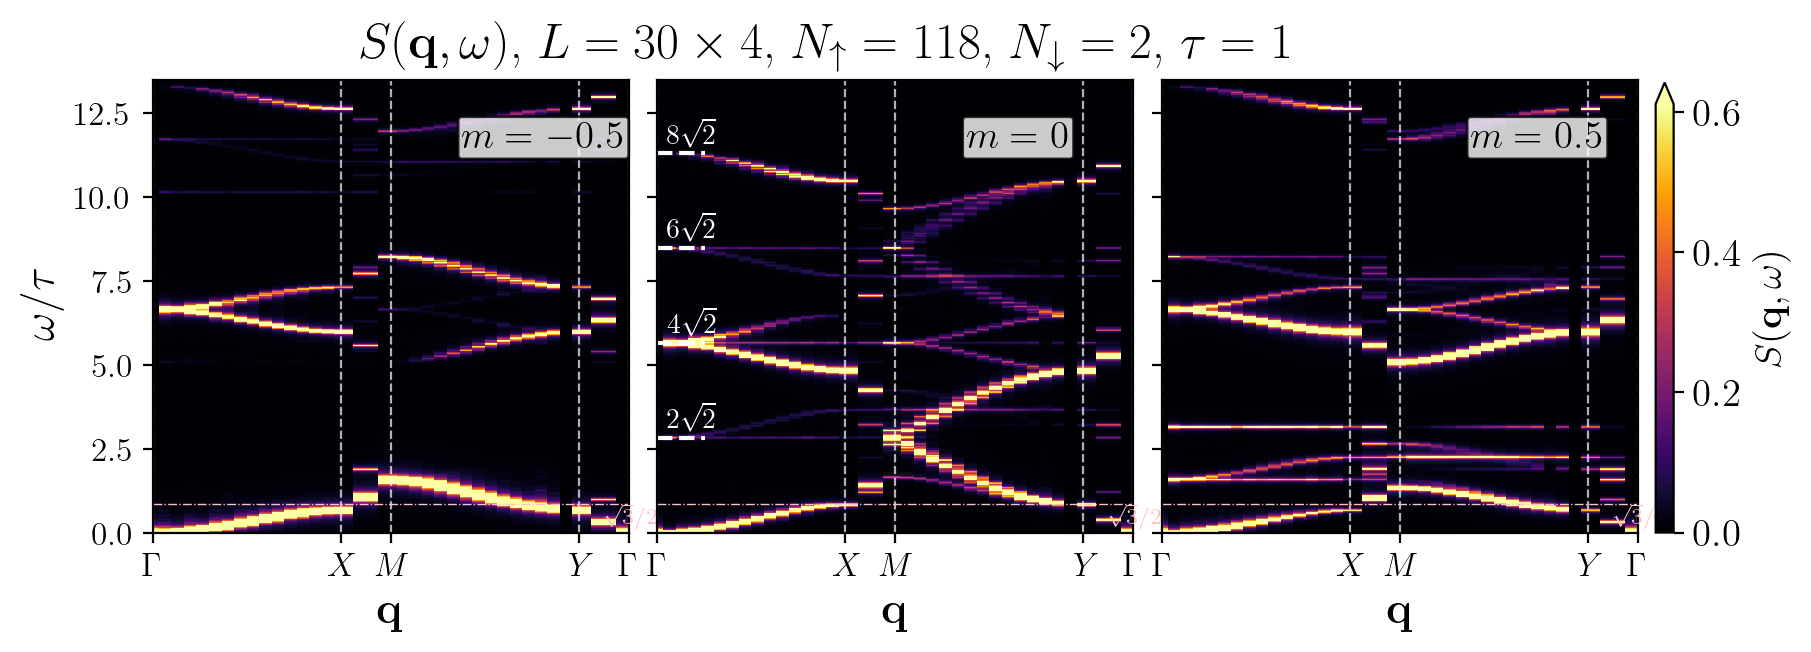

In [ ]:
Lx = 30
Ly = 4
Nu = -1
Nd = 2
tau = 1
mass = 0
BC = 1 #PBC: BC=1

V = Lx*Ly

if Nu < 0:
    Nu = Lx * Ly - Nd
if Nd < 0:
    Nd = Lx * Ly - Nu

fig, ax = plt.subplots( nrows=1, ncols=3, figsize=(9,3), dpi = 200, sharey=True)
mas = [-0.5, 0.0, 0.5]

for iim, mass in enumerate(mas):
    axis = ax[iim]
    name = base_dir(BC) + "DynamicalStructureFactor/Spin/" + info(Lx, Ly, Nu, Nd, tau, mass, ',kx=0,ky=0,px=1,py=1.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            omegas = np.array(file.get('omegas'))[0]
            # if np.abs(mass) > 0: omegas /= np.sqrt(mass)
            Sqw = np.array(file.get('Sqw'))
    else:
        print(name)
    # ----------------------------------------------------------------
    # 1. Reconstruct the BZ path (same order as stored in file)
    # ----------------------------------------------------------------
    path, q_vals, label_positions = get_bz_path(Lx, Ly)
    q_vals = get_weighted_qvals(path, label_positions, scale_factor=2.0)

    n_q = len(path)
    Q, W = np.meshgrid(q_vals, omegas)  # (n_omega, n_q)

    p = axis.pcolormesh(
        Q, W,
        Sqw,                           # (n_omega, n_q)
        shading    = 'nearest',
        cmap       = 'inferno',
        vmin       = 0,
        vmax       = np.percentile(Sqw, 99),
        rasterized = True
    )
    # fig_help.set_plot_elements(axis, font_size=16, set_legend=0)
    # High-symmetry labels and vertical lines
    xtick_pos    = [q_vals[i] for i in label_positions]
    xtick_labels = list(label_positions.values())
    axis.set_xticks(xtick_pos)
    axis.set_xticklabels(xtick_labels, fontsize=14)
    for idx in label_positions:
        axis.axvline(x=q_vals[idx], color='white',
                    linewidth=0.8, linestyle='--', alpha=0.7)

    if iim==0: axis.set_ylabel(r"$\omega/\tau$",      fontsize=16)
    axis.set_xlabel(r"$\mathbf{q}$",  fontsize=16)
    axis.set_xlim(q_vals[0], q_vals[-1])
    axis.set_ylim(omegas.min(), omegas.max())
    axis.tick_params(labelsize=12)
    # for n in range(1, 11):  
    #         axis.axhline(y = n, ls='--', color='red', lw=0.5)
    axis.axhline(y = np.sqrt(3)/2, ls='-.', color='pink', lw=0.5)
    axis.annotate(r"$\sqrt{3}/2$", fontsize=8, xy=(0.3*V, np.sqrt(3)/2 - 0.6), xycoords='data', color='pink')
    if mass == 0:
        for n in range(2, 9, 2): 
            axis.axhline(y = n*np.sqrt(2), xmax=0.1, ls='--', color='white', lw=1.5)
            axis.annotate(r"$%d\sqrt{2}$"%n if n > 1 else r"$\sqrt{2}$", fontsize=10, xy=(0.75, (n+0.2)*np.sqrt(2)), xycoords='data', color='white')
        
        # axis.axhline(y = 2*np.sqrt(6), ls=':', color='green', lw=1)
        # axis.axhline(y = np.sqrt(111), ls=':', color='green', lw=1)
    # else:
    #     # axis.axhline(y = 10 - np.abs(mass), ls='-.', color='pink', lw=0.5)
    #     for n in range(1, 5):  
    #         axis.axhline(y = n/2, ls='--', color='red', lw=0.5)
            # axis.axhline(y = n*np.sqrt(1)/2, ls='-.', color='pink', lw=0.5)
        # for n in range(8, 11): axis.axhline(y = n*np.sqrt(np.abs(mass)), ls='--', color='red', lw=0.5)
    
    axis.set_ylim(0, 13.5)
    
    axis.annotate(r"$m=%g$"%mass, fontsize=14, xy=(0.65, 0.85), xycoords='axes fraction', color='k',
           bbox=dict(boxstyle="round,pad=0.1", 
                     facecolor='white', 
                     edgecolor='black', 
                     alpha=0.8))
# Colorbar
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.01, 0.75])
cbar    = fig.colorbar(p, cax=cbar_ax, orientation='vertical', extend='max')
cbar.set_label(r"$S(\mathbf{q},\omega)$", fontsize=14)
cbar.ax.tick_params(labelsize=14)

fig.suptitle(
    rf"$S(\mathbf{{q}},\omega)$,  $L={Lx}\times{Ly}$,  "
    rf"$N_\uparrow={Nu}$,  $N_\downarrow={Nd}$,  $\tau=1$",
    fontsize=18
)
fig.subplots_adjust(wspace = 0.06, hspace=0.06)

Always check what symmetry sector is global ground state in

BZ path for 20x2 non-square lattice:
  Total q-points: 23
  $\Gamma$      idx=  0  ( 0, 0)  q=(0.000, 0.000)  dist=0.0000
  $X$           idx= 10  (10, 0)  q=(3.142, 0.000)  dist=3.1416
  $M$           idx= 11  (10, 1)  q=(3.142, 3.142)  dist=6.2832
  $Y$           idx= 21  ( 0, 1)  q=(0.000, 3.142)  dist=9.4248
  $\Gamma$      idx= 22  ( 0, 0)  q=(0.000, 0.000)  dist=12.5664
  Segment steps : [10, 1, 10, 1]
  Max steps     : 10
  Min steps     : 1
  Segment 0: $\Gamma$     -> $X$           steps= 10  bin_width=1.0
  Segment 1: $X$          -> $M$           steps=  1  bin_width=1.0
  Segment 2: $M$          -> $Y$           steps= 10  bin_width=1.0
  Segment 3: $Y$          -> $\Gamma$      steps=  1  bin_width=1.0
BZ path for 20x2 non-square lattice:
  Total q-points: 23
  $\Gamma$      idx=  0  ( 0, 0)  q=(0.000, 0.000)  dist=0.0000
  $X$           idx= 10  (10, 0)  q=(3.142, 0.000)  dist=3.1416
  $M$           idx= 11  (10, 1)  q=(3.142, 3.142)  dist=6.2832
  $Y$           idx= 21  

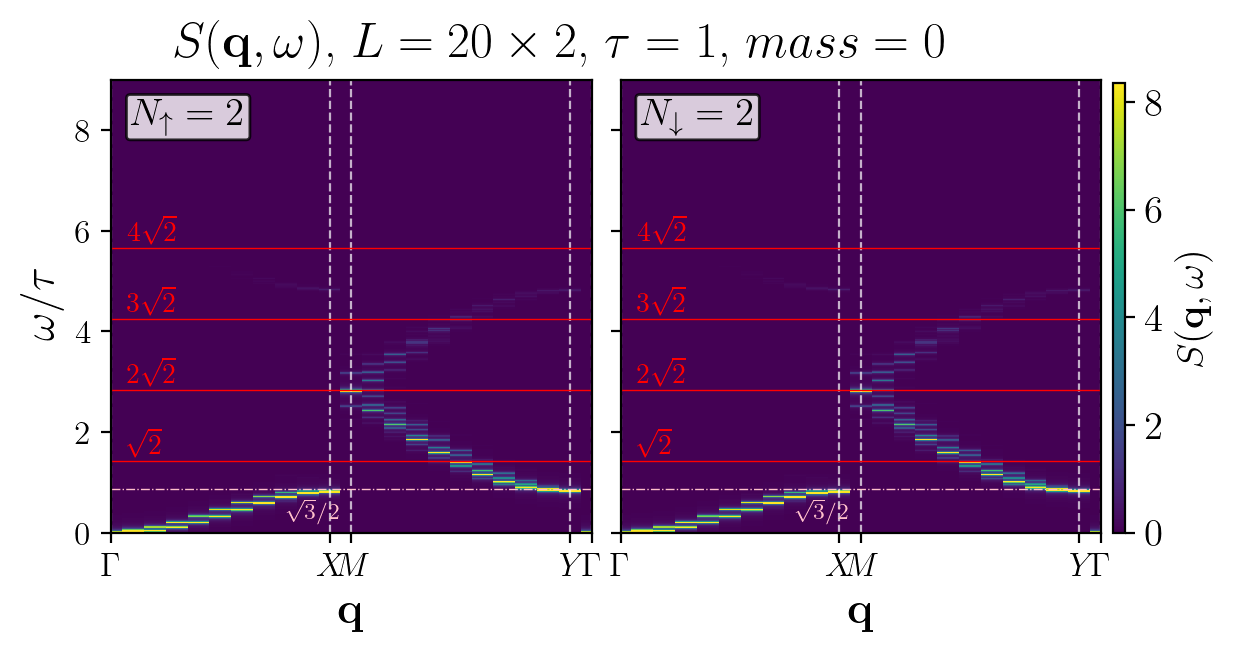

In [296]:
Lx = 20
Ly = 2
Nu = 2
Nd = -1
tau = 1
mass = 0
BC = 1 #PBC: BC=1

V = Lx*Ly

fig, ax = plt.subplots( nrows=1, ncols=2, figsize=(6,3), dpi = 200, sharey=True)
mas = [-0.5, 0.0, 0.5]

mass = 0
for iim, [Nu, Nd] in enumerate([[2, -1], [-1, 2]]):

    if Nu < 0:
        Nu = Lx * Ly - Nd
    if Nd < 0:
        Nd = Lx * Ly - Nu
    axis = ax[iim]
    name = base_dir(BC) + "DynamicalStructureFactor/Spin/" + info(Lx, Ly, Nu, Nd, tau, mass, ',kx=0,ky=0,px=1,py=1.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            omegas = np.array(file.get('omegas'))[0]
            # if np.abs(mass) > 0: omegas /= np.sqrt(mass)
            Sqw = np.array(file.get('Sqw'))
    else:
        print(name)
    # ----------------------------------------------------------------
    # 1. Reconstruct the BZ path (same order as stored in file)
    # ----------------------------------------------------------------
    path, q_vals, label_positions = get_bz_path(Lx, Ly)
    q_vals = get_weighted_qvals(path, label_positions, scale_factor=1.0)

    n_q = len(path)
    Q, W = np.meshgrid(q_vals, omegas)  # (n_omega, n_q)

    p = axis.pcolormesh(
        Q, W,
        Sqw,                           # (n_omega, n_q)
        shading    = 'nearest',
        cmap       = 'viridis',
        vmin       = 0,
        vmax       = np.percentile(Sqw, 99.9),
        rasterized = True
    )
    # fig_help.set_plot_elements(axis, font_size=16, set_legend=0)
    # High-symmetry labels and vertical lines
    xtick_pos    = [q_vals[i] for i in label_positions]
    xtick_labels = list(label_positions.values())
    axis.set_xticks(xtick_pos)
    axis.set_xticklabels(xtick_labels, fontsize=14)
    for idx in label_positions:
        axis.axvline(x=q_vals[idx], color='white',
                    linewidth=0.8, linestyle='--', alpha=0.7)

    if iim==0: axis.set_ylabel(r"$\omega/\tau$",      fontsize=16)
    axis.set_xlabel(r"$\mathbf{q}$",  fontsize=16)
    axis.set_xlim(q_vals[0], q_vals[-1])
    axis.set_ylim(omegas.min(), omegas.max())
    axis.tick_params(labelsize=12)
    # for n in range(1, 11):  
    #         axis.axhline(y = n, ls='--', color='red', lw=0.5)
    if mass == 0:
        for n in range(1, 5): 
            axis.axhline(y = n*np.sqrt(2), ls='-', color='red', lw=0.5)
            axis.annotate(r"$%d\sqrt{2}$"%n if n > 1 else r"$\sqrt{2}$", fontsize=10, xy=(0.75, (n+0.1)*np.sqrt(2)), xycoords='data', color='red')
        axis.axhline(y = np.sqrt(3)/2, ls='-.', color='pink', lw=0.5)
        axis.annotate(r"$\sqrt{3}/2$", fontsize=8, xy=(0.2*V, np.sqrt(3)/2 - 0.6), xycoords='data', color='pink')
        # axis.axhline(y = 2*np.sqrt(6), ls=':', color='green', lw=1)
        # axis.axhline(y = np.sqrt(111), ls=':', color='green', lw=1)
    else:
        # axis.axhline(y = 10 - np.abs(mass), ls='-.', color='pink', lw=0.5)
        for n in range(1, 5):  
            axis.axhline(y = n/2, ls='--', color='red', lw=0.5)
            # axis.axhline(y = n*np.sqrt(1)/2, ls='-.', color='pink', lw=0.5)
        # for n in range(8, 11): axis.axhline(y = n*np.sqrt(np.abs(mass)), ls='--', color='red', lw=0.5)
    
    axis.set_ylim(0, 9)
    lab = r"$N_\uparrow=%d$"%Nu if Nu < Nd else r"$N_\downarrow=%d$"%Nd
    axis.annotate(lab, fontsize=14, xy=(0.04, 0.9), xycoords='axes fraction', color='k',
           bbox=dict(boxstyle="round,pad=0.1", 
                     facecolor='white', 
                     edgecolor='black', 
                     alpha=0.8))
# Colorbar
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.01, 0.75])
cbar    = fig.colorbar(p, cax=cbar_ax, orientation='vertical')
cbar.set_label(r"$S(\mathbf{q},\omega)$", fontsize=14)
cbar.ax.tick_params(labelsize=14)

fig.suptitle(
    rf"$S(\mathbf{{q}},\omega)$,  $L={Lx}\times{Ly}$,  $\tau=1$,  $mass={mass}$",
    fontsize=18
)
fig.subplots_adjust(wspace = 0.06, hspace=0.06)